In [24]:
left_eye = [33, 133, 144, 153, 158, 160]
right_eye = [263, 362, 373, 380, 385, 387]
nose = [(168, 6, 197, 195, 5, 4, 1, 94), (20, 250), (360, 131), (48, 278), (166, 392), (99, 326)]
lips = [(0, 17), (39, 269), (185, 409), (181, 405),13, (146, 375), (81, 311), (191, 415)]
left_cheek = [123, 205, 192, 187, 206, 214, 216, 143, 117, 119]
right_cheek = [352, 425, 416, 411, 426, 434, 436, 372, 346, 348]
left_eye_brow = [46, 52, 53, 65]
right_eye_brow = [295, 283, 276, 282]
jaw = [214, 204, 201, 421, 424, 434]
outer = [137, 215, 135, 170, 171, 396, 395, 364, 435, 366, 264, 301, 333, 337, 108, 104, 71, 34]

target_parts = [left_eye, right_eye, nose, lips, left_cheek, right_cheek, left_eye_brow, right_eye_brow, jaw, outer]

index = []

for t in target_parts:
    for i in t:
        if isinstance(i, int):
            index.append(i)
        else:
            for ii in i:
                index.append(ii)

In [25]:
type(index[0])

int

In [28]:
len(index)

97

../data/archive/FaceForensics++_C23/crops/DeepFakeDetection\01_02__meeting_serious__YVGY8LOK\0_0.png
총 랜드마크 개수: 97
랜드마크 0: x=40, y=56
랜드마크 1: x=64, y=59
랜드마크 2: x=47, y=59
랜드마크 3: x=55, y=60
랜드마크 4: x=55, y=53
랜드마크 5: x=46, y=53
랜드마크 6: x=113, y=61
랜드마크 7: x=91, y=61
랜드마크 8: x=107, y=64
랜드마크 9: x=98, y=63
랜드마크 10: x=100, y=56
랜드마크 11: x=108, y=57
랜드마크 12: x=80, y=54
랜드마크 13: x=80, y=59
랜드마크 14: x=80, y=65
랜드마크 15: x=81, y=69
랜드마크 16: x=81, y=75
랜드마크 17: x=81, y=81
랜드마크 18: x=81, y=86
랜드마크 19: x=79, y=91
랜드마크 20: x=74, y=89
랜드마크 21: x=84, y=90
랜드마크 22: x=92, y=81
랜드마크 23: x=66, y=80
랜드마크 24: x=62, y=85
랜드마크 25: x=94, y=87
랜드마크 26: x=66, y=87
랜드마크 27: x=91, y=88
랜드마크 28: x=71, y=91
랜드마크 29: x=85, y=92
랜드마크 30: x=78, y=103
랜드마크 31: x=76, y=115
랜드마크 32: x=63, y=103
랜드마크 33: x=90, y=105
랜드마크 34: x=54, y=106
랜드마크 35: x=96, y=109
랜드마크 36: x=63, y=113
랜드마크 37: x=88, y=115
랜드마크 38: x=77, y=108
랜드마크 39: x=54, y=109
랜드마크 40: x=95, y=112
랜드마크 41: x=65, y=107
랜드마크 42: x=86, y=109
랜드마크 43: x=57, y=1

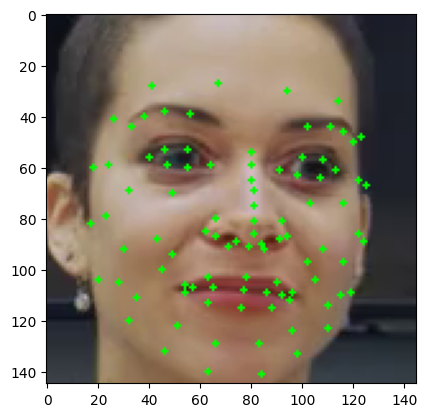

In [26]:
import cv2
# 최신 버전에서는 이렇게 불러옵니다
from mediapipe.python.solutions import face_mesh
from mediapipe.python.solutions import drawing_utils as mp_drawing
import os
import matplotlib.pyplot as plt
import numpy as np

# 이미지 불러오기
DFD_PATH = "../data/archive/FaceForensics++_C23/crops/DeepFakeDetection"
image_folders = os.listdir(DFD_PATH)
sample_folder = image_folders[0]
sample_folder_path = os.path.join(DFD_PATH, sample_folder)
sample_file = os.listdir(sample_folder_path)[0]
image_path = os.path.join(sample_folder_path, sample_file)
print(image_path)
image = cv2.imread(image_path)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

landmarks = []

# FaceMesh 객체 생성
with face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5) as mesh:

    results = mesh.process(rgb_image)

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            print("총 랜드마크 개수:", len(np.array(face_landmarks.landmark[:])[index]))
            for idx, lm in enumerate(np.array(face_landmarks.landmark[:])[index]):
                x = int(lm.x * image.shape[1])
                y = int(lm.y * image.shape[0])
                print(f"랜드마크 {idx}: x={x}, y={y}")
                landmarks.append([x,y])

                cv2.circle(image, (x, y), 1, (0, 255, 0), -1)

final_image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(final_image_rgb)
plt.show()

In [36]:
print(len(landmarks))

97
